# **Telecomunicaciones: Identificación de Operadores Ineficaces**
## Identificar operadores ineficaces
El servicio de telefonía virtual __CallMeMaybe__ está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

Por lo tanto, es necesario desarrollar:
* Análisis Exploratorio de datos
* Identificar operadores ineficaces
* Prueba de Hipótesis Estadísticas

Los datasets contienen información sobre el uso del servicio de telefonía virtual __CallMeMaybe__. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

### Carga y exploración de datos

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga de información
data = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Telecomunicaciones Identificación de Operadores Ineficaces\CSV Telecomunicaciones Identificación de Operadores Ineficaces\telecom_dataset_new.csv")
clients = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Telecomunicaciones Identificación de Operadores Ineficaces\CSV Telecomunicaciones Identificación de Operadores Ineficaces\telecom_clients.csv")

In [3]:
# Cargar la información del Dataset
data.info()
print('==========================================================================================================================')
print(data.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     Tru

In [4]:
# Cargar la información del Dataset
clients.info()
print('==========================================================================================================================')
print(clients.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16
5   167764           A  2019-09-30
6   167050           A  2019-08-29
7   168252           A  2019-10-17
8   168495           A  2019-10-28
9   167879           A  2019-10-03


In [5]:
# Cambiar el Dtype de la columna 'operator_id' a str
data['operator_id'] = (
    data['operator_id']
    .astype('Int64', errors='ignore')
    .astype(str)
    .replace(['NaN','<NA>','nan'], 'NaN')
)

In [6]:
# Presenta el Dataset de Telecom fechas, lo que es importante convertir a 'datetime'

# Convertir fechas
data['date'] = pd.to_datetime(data['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Visualización de Información del Dtype de ambos dataset
data.info()
print('==========================================================================================================================')
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[us, UTC+03:00]
 2   direction            53902 non-null  str                      
 3   internal             53785 non-null  object                   
 4   operator_id          45730 non-null  str                      
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: bool(1), datetime64[us, UTC+03:00](1), int64(4), object(1), str(2)
memory usage: 3.3+ MB
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 7

In [7]:
# Además, vemos que hay valores ausentes en el dataset de Telecom -> 'operador_id' & 'internal'
print(f'Valores ausentes del dataset "data":')
print(f'{data.isna().sum()}')
print('==========================================================================================================================')
print(f'Valores ausentes del dataset "clients":')
print(clients.isna().sum())

Valores ausentes del dataset "data":
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64
Valores ausentes del dataset "clients":
user_id        0
tariff_plan    0
date_start     0
dtype: int64


##### Comentario
Se detectó una cantidad considerable de valores ausentes en __operator_id__. Estos registros se conservaron inicialmente para el análisis exploratorio debido a que podían representar llamadas no asignadas o abandonadas. También sucede algo similar en la columna __internal__, pero con una menor magnitud. Para efectos del ejercicio, no rellenaremos con ningún dato por el momento los valores ausentes, para no alterar los resultados del análisis.

In [8]:
# Búsqueda de filas duplicadas en ambos dataset
print(f'Valores duplicados de "data": {data.duplicated().sum()}')
print(f'Valores duplcados de "clients:"{clients.duplicated().sum()}')

Valores duplicados de "data": 4900
Valores duplcados de "clients:"0


In [9]:
# Debemos eliminar los valores duplicados del dataset 'data'
data = data.drop_duplicates()
print(f'Valores duplicados de "data" posterior a la eliminación de duplicados: {data.duplicated().sum()}')

Valores duplicados de "data" posterior a la eliminación de duplicados: 0


### Análisis exploratorio (EDA)

In [10]:
# Cantidad de clientes
qn_user = data['user_id'].nunique()

print(f'Cantidad de Usuarios: {qn_user}')

Cantidad de Usuarios: 307


In [11]:
# Periodo de recopilación de estadísticas
date_min = data['date'].min()
date_max = data['date'].max()

days_data = (date_max - date_min).days

print(f'Fecha mínima de recopilación de datos del dataset "data": {date_min}')
print(f'Fecha máxima de recopilación de datos del dataset "data": {date_max}')
print(f'La cantidad de días de estudio son: {days_data}')

Fecha mínima de recopilación de datos del dataset "data": 2019-08-02 00:00:00+03:00
Fecha máxima de recopilación de datos del dataset "data": 2019-11-28 00:00:00+03:00
La cantidad de días de estudio son: 118


In [12]:
# Cantidad de llamadas entrantes y salientes
n_in = data[data['direction'] == 'in']['direction'].count()
n_out = data[data['direction'] == 'out']['direction'].count()

print(f'Cantidad de llamadas entrantes: {n_in}')
print(f'Cantidad de llamadas salientes: {n_out}')

Cantidad de llamadas entrantes: 20003
Cantidad de llamadas salientes: 28999


In [13]:
# Cantidad de llamadas internas
int_true = data[data['internal'] == True]['internal'].count()
int_false = data[data['internal'] == False]['internal'].count()

print(f'Cantidad de llamadas internas: {int_true}')
print(f'Cantidad de llamadas externas: {int_false}')

Cantidad de llamadas internas: 5653
Cantidad de llamadas externas: 43239


In [14]:
# Cantidad de Operadores
qn_operators = data['operator_id'].nunique()

print(f'Cantidad de Operadores: {qn_operators}')

Cantidad de Operadores: 1092


direction       in     out
operator_id               
879896        58.0   872.0
879898       104.0  7209.0
880020         7.0    38.0
880022         8.0   189.0
880026        24.0  2208.0
880028        63.0  2497.0
880240         NaN    47.0
881278         NaN    20.0
882476         3.0     NaN
882478         3.0     1.0
882680        99.0     NaN
882684       613.0   661.0
882686       766.0  2884.0
882688        15.0    43.0
882690       171.0  1417.0


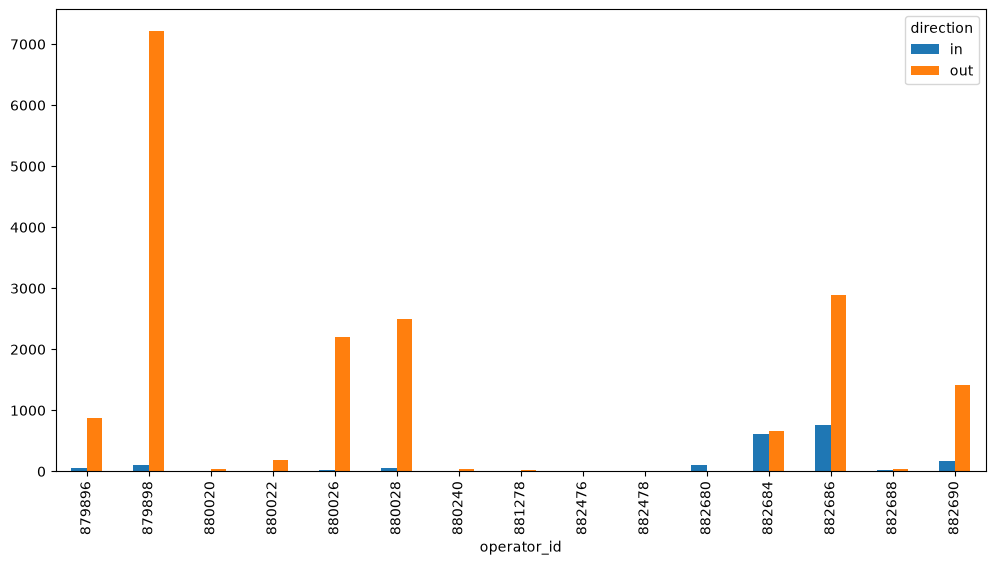

In [15]:
# Entrantes vs Salientes por Operador

# Primero excluir los 'operator_id' nulos
data['operator_id'] = data['operator_id'].replace(
    ['NaN', 'nan', '<NA>'],
    np.nan
)
operators_data = data.dropna(
    subset=['operator_id']
)

direction_operator=(
    operators_data.pivot_table(
        index = 'operator_id',
        columns = 'direction',
        values = 'calls_count',
        aggfunc = 'sum'
    )
)

print(direction_operator.head(15))

direction_operator.head(15).plot(
    kind = 'bar',
    figsize = (12,6)
)
plt.show()

In [16]:
# Cantidad de llamadas perdidas
miss_call = data[data['is_missed_call'] == True]['is_missed_call'].count()
reply_call = data[data['is_missed_call'] == False]['is_missed_call'].count()

print(f'Cantidad de llamadas perdidas: {miss_call}')
print(f'Cantidad de llamadas respondidas: {reply_call}')

Cantidad de llamadas perdidas: 21453
Cantidad de llamadas respondidas: 27549


In [17]:
# Ranking de Cantidad de llamadas por usuario
calls_count_users = data.groupby('user_id')['calls_count'].sum()

rank_calls_count_users = calls_count_users.sort_values(ascending = False).reset_index()

print(f'Ranking de Cantidad de llamadas por Usuario')
print(rank_calls_count_users.head(20))

Ranking de Cantidad de llamadas por Usuario
    user_id  calls_count
0    166582       144500
1    167626        93406
2    168361        82708
3    167827        40673
4    168252        26504
5    168062        25357
6    168187        21398
7    166405        17536
8    167125        15286
9    167285        14349
10   168018        13012
11   166658        12794
12   167650        12645
13   167071        10337
14   166782         9687
15   166983         8881
16   166406         8386
17   167150         8010
18   166511         7892
19   166485         7489


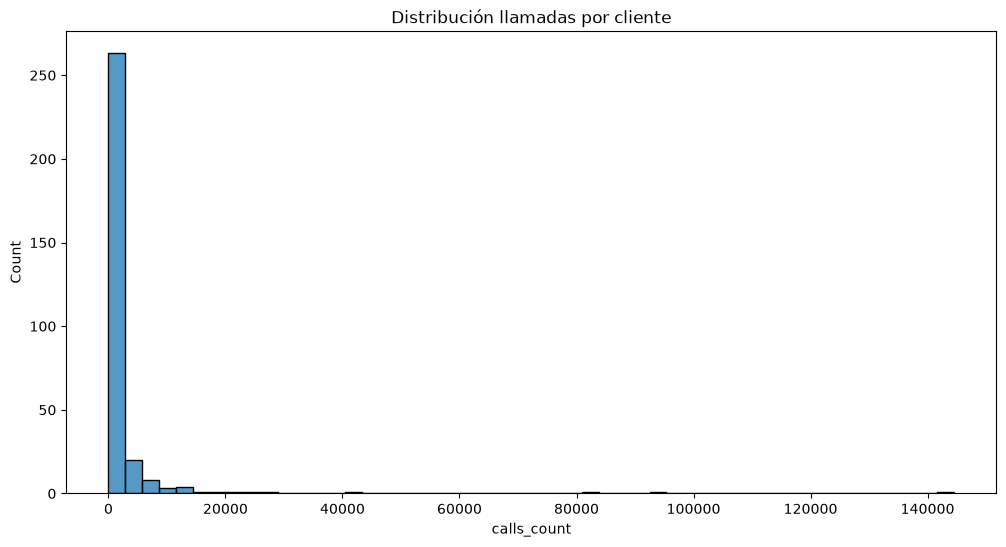

In [18]:
# Visualización de Clientes más intensivos
plt.figure(figsize=(12,6))
sns.histplot(
    calls_count_users,
    bins=50
)
plt.title('Distribución llamadas por cliente')
plt.show()

In [19]:
# Ranking de Cantidad de llamadas por operario
calls_count_operator = (
    operators_data
    .groupby('operator_id')
    ['calls_count']
    .sum()
)

rank_calls_count_operator = calls_count_operator.sort_values(ascending = False).reset_index()

print(f'Ranking de Cantidad de llamadas por Operario')
print(rank_calls_count_operator.head(20))

Ranking de Cantidad de llamadas por Operario
   operator_id  calls_count
0       885890        60221
1       885876        59429
2       929428        23754
3       925922        20021
4       908640        14239
5       929426        11189
6       879898         7313
7       945286         6880
8       945302         6138
9       893804         5846
10      929424         5229
11      913938         5174
12      921318         4883
13      919364         4820
14      945322         4775
15      904016         4731
16      952948         4720
17      931458         4441
18      945900         4210
19      901880         4187


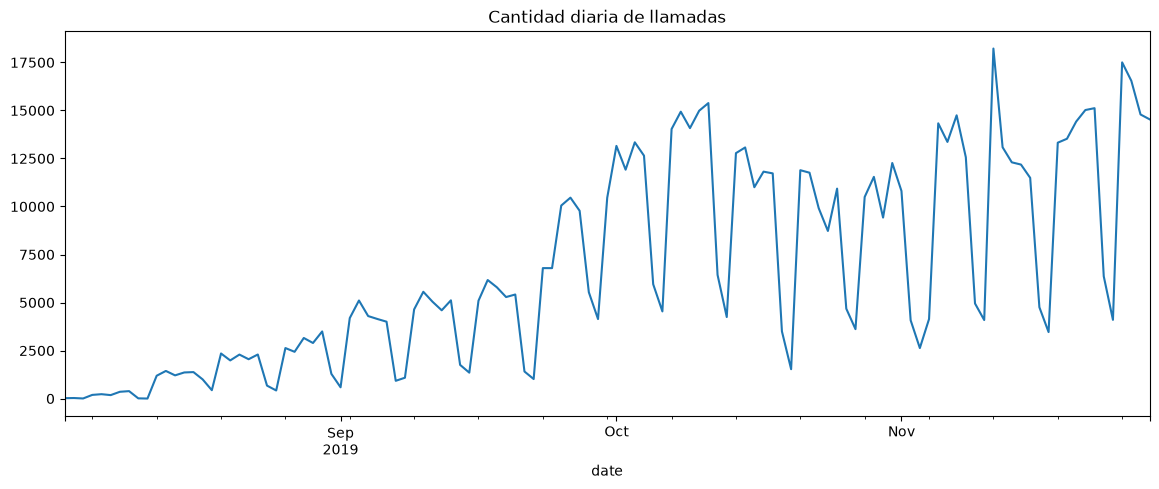

In [20]:
# Actividad diaria
calls_day = (
    data.groupby('date')
    ['calls_count']
    .sum()
)
plt.figure(figsize=(14,5))
calls_day.plot()
plt.title('Cantidad diaria de llamadas')
plt.show()

In [21]:
# Actividad semanal
data['weekday'] = data['date'].dt.day_name()

data_week = data.groupby('weekday')['calls_count'].sum()

print(data_week.sort_values())

weekday
Sunday        37255
Saturday      53349
Friday       132549
Monday       139918
Wednesday    143218
Thursday     148757
Tuesday      151663
Name: calls_count, dtype: int64


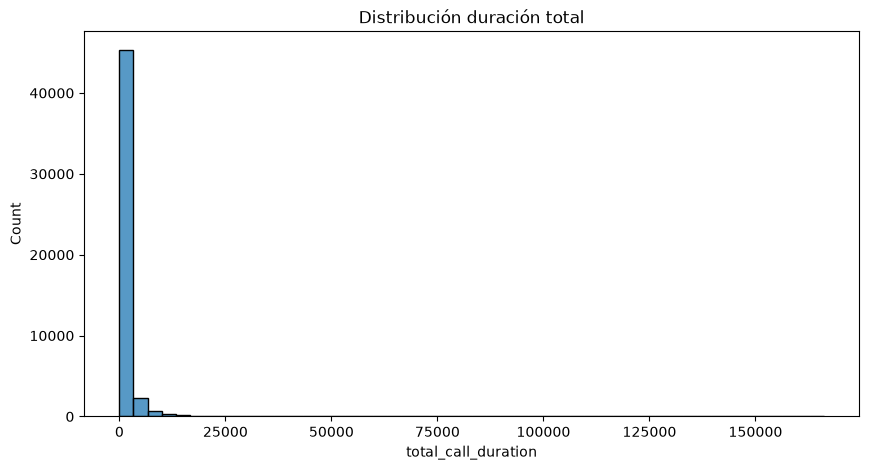

In [22]:
# Distribución de Duración de llamadas
plt.figure(figsize=(10,5))
sns.histplot(
    data['total_call_duration'],
    bins=50
)
plt.title('Distribución duración total')
plt.show()

In [23]:
# Detectar outliers
perc_tcd = data['total_call_duration'].describe(
    percentiles=[.25,.5,.75,.95,.99]
)
print(perc_tcd.round(2))

count     49002.00
mean       1156.56
std        4451.47
min           0.00
25%          46.00
50%         208.00
75%         901.00
95%        4531.00
99%       12956.00
max      166155.00
Name: total_call_duration, dtype: float64


#### Conclusiones EDA
El análisis exploratorio permitió comprender la estructura y el comportamiento general del servicio telefónico CallMeMaybe. El conjunto de datos contiene información correspondiente a 307 clientes y 1093 operadores recopilada durante un período de 118 días. Se observó una mayor cantidad de llamadas salientes respecto a las entrantes, además de una clara predominancia de llamadas externas sobre llamadas internas, lo que sugiere una operación orientada principalmente a interacción con clientes externos.

Asimismo, el volumen de llamadas presenta una distribución desigual entre clientes, donde un pequeño grupo concentra una parte importante del tráfico total. También se identificó un patrón temporal en la actividad telefónica: los días laborales concentran una mayor carga operacional, mientras que los fines de semana presentan una disminución significativa del volumen de llamadas.

Finalmente, las variables relacionadas con duración de llamadas muestran distribuciones asimétricas y presencia de valores extremos, indicando diferencias importantes en la intensidad y comportamiento del uso del sistema. Estos hallazgos entregan contexto operacional y permiten avanzar hacia el análisis específico de desempeño e identificación de operadores potencialmente ineficaces.

### Métricas de Ineficiencia

In [24]:
# Ratio de llamadas perdidas
loss_rate = (
    miss_call /
    (miss_call + reply_call)
)*100

print(f'Ratio de llamadas perdidas: {loss_rate.round(2)}%')

Ratio de llamadas perdidas: 43.78%


count    49002.00
mean       290.28
std       1132.16
min          0.00
25%         17.00
50%         55.00
75%        200.00
max      46474.00
Name: waiting_time, dtype: float64


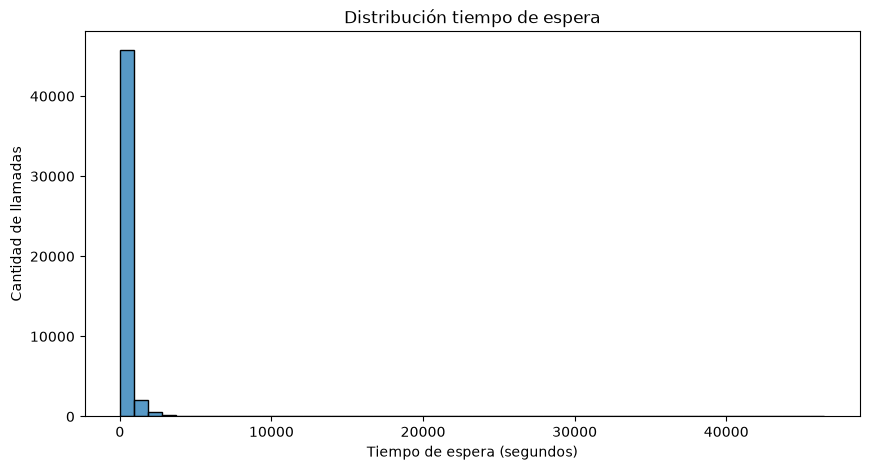

In [25]:
# Distribución de tiempo de espera
data['waiting_time'] = (
    data['total_call_duration'] - data['call_duration']
)
print(data['waiting_time'].describe().round(2))

plt.figure(figsize=(10,5))
sns.histplot(
    data['waiting_time'],
    bins=50
)
plt.title('Distribución tiempo de espera')
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Cantidad de llamadas')
plt.show()

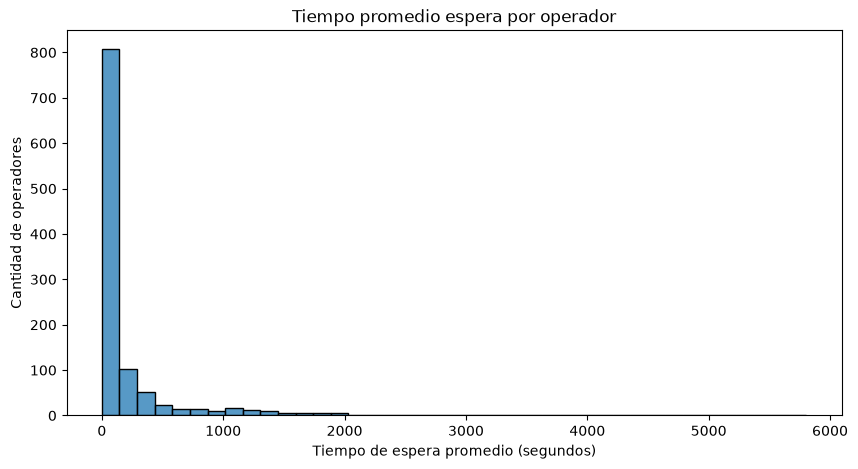

In [26]:
# Tiempo de espera por operador
operators_data = data.dropna(
    subset=['operator_id']
).copy()

operators_data['waiting_time'] = (
    operators_data['total_call_duration'] - operators_data['call_duration']
)

wait_operator = (
    operators_data.groupby('operator_id')['waiting_time'].mean()
)

plt.figure(figsize=(10,5))
sns.histplot(
    wait_operator,
    bins = 40
)
plt.title('Tiempo promedio espera por operador')
plt.xlabel('Tiempo de espera promedio (segundos)')
plt.ylabel('Cantidad de operadores')
plt.show()

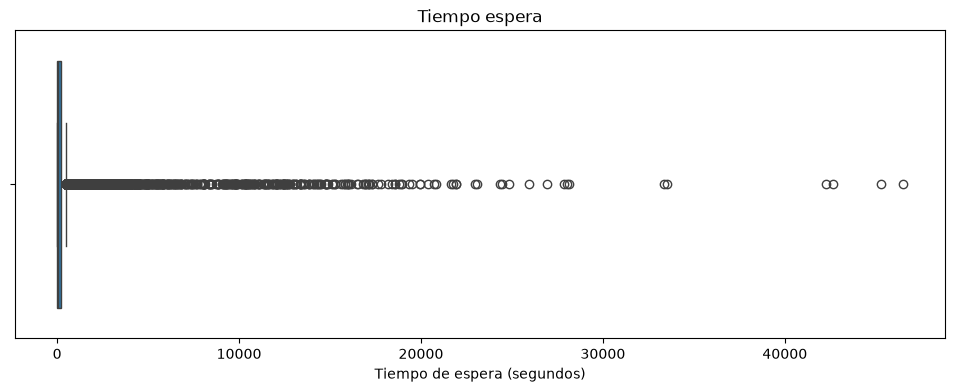

In [27]:
# Boxplot de Tiempo de Espera
plt.figure(figsize=(12,4))
sns.boxplot(
    x = data['waiting_time']
)
plt.title('Tiempo espera')
plt.xlabel('Tiempo de espera (segundos)')
plt.show()

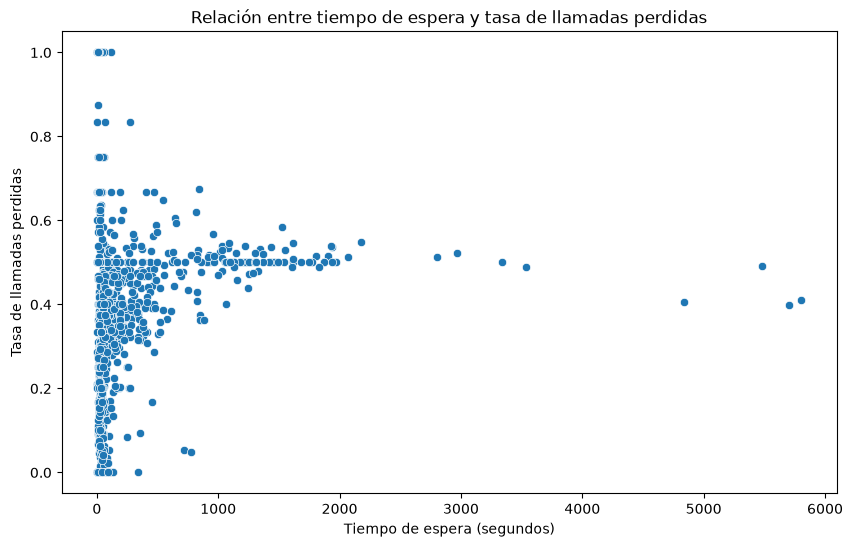

In [28]:
# Relación llamadas perdidas vs tiempo de espera
operator_metrics = data.groupby(
    'operator_id'
    ).agg(
        miss_rate=('is_missed_call','mean'),
        wait=('waiting_time','mean')
    )
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = operator_metrics,
    x = 'wait',
    y = 'miss_rate'
)
plt.title('Relación entre tiempo de espera y tasa de llamadas perdidas')
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Tasa de llamadas perdidas')
plt.show()

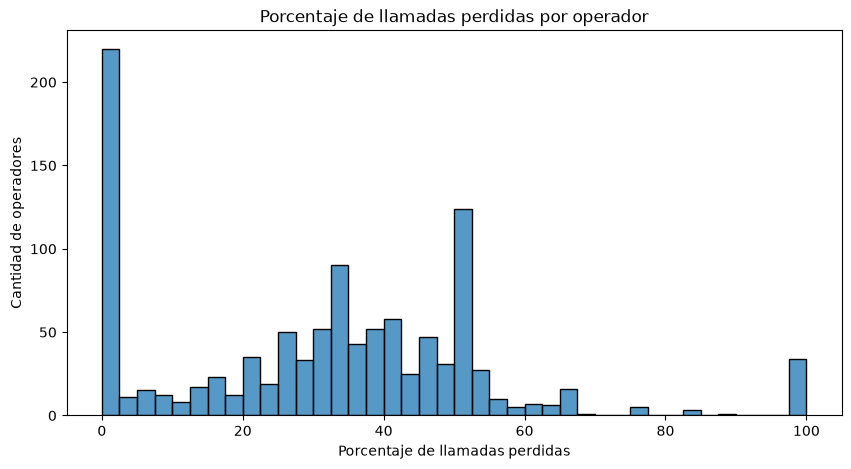

In [29]:
# Distribución de llamadas perdidas por operador
missed_by_operator = (
    data.groupby('operator_id')['is_missed_call']
    .mean()*100
)

plt.figure(figsize=(10,5))
sns.histplot(
    missed_by_operator,
    bins=40
)
plt.title('Porcentaje de llamadas perdidas por operador')
plt.xlabel('Porcentaje de llamadas perdidas')
plt.ylabel('Cantidad de operadores')
plt.show()

count      882.00
mean       689.73
std       3122.95
min          1.00
25%         11.00
50%         90.00
75%        597.25
max      58977.00
Name: calls_count, dtype: float64


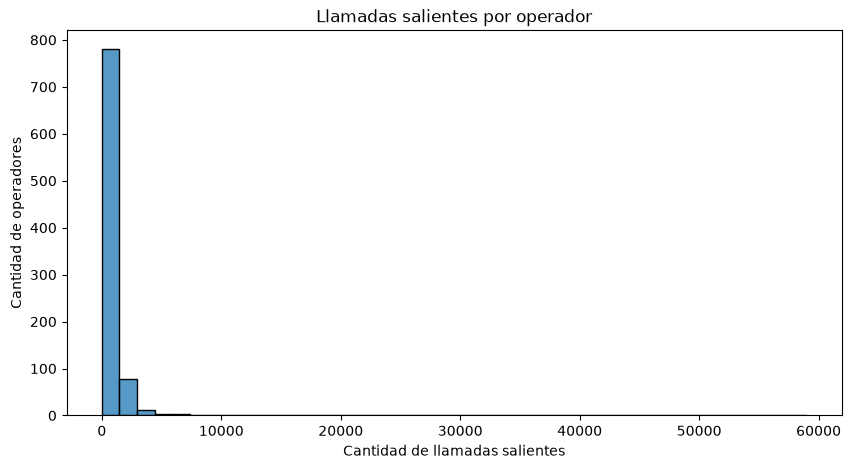

In [30]:
# Llamadas salientes por operador
out_calls_operator = (
    operators_data[operators_data['direction']=='out']
    .groupby('operator_id')['calls_count']
    .sum()
)

print(out_calls_operator.describe().round(2))

plt.figure(figsize=(10,5))
sns.histplot(
    out_calls_operator,
    bins=40
)
plt.title('Llamadas salientes por operador')
plt.xlabel('Cantidad de llamadas salientes')
plt.ylabel('Cantidad de operadores')
plt.show()

In [31]:
# Operadores con 100% de llamadas perdidas
operators_100 = (
    missed_by_operator[missed_by_operator==100]
)

print(f'Cantidad de Operadores con 100% de llamadas perdidas: {len(operators_100)}')

Cantidad de Operadores con 100% de llamadas perdidas: 34


#### Conclusiones
El análisis de métricas operacionales permitió identificar indicadores relevantes para evaluar la eficacia de los operadores. En primer lugar, el sistema presenta una tasa global de llamadas perdidas de 43.78%, porcentaje considerablemente elevado y que sugiere oportunidades de mejora en la gestión de llamadas.

La distribución del tiempo de espera presenta una fuerte asimetría positiva. Mientras la mediana alcanza solo 55 segundos, la media aumenta a 290 segundos debido a valores extremos. La presencia de múltiples outliers indica que algunos casos experimentan tiempos de espera excepcionalmente altos.

Al analizar el tiempo promedio por operador se observa una alta variabilidad entre operadores. Aunque la mayoría presenta tiempos relativamente bajos, existe un grupo reducido con esperas considerablemente superiores al promedio, lo que podría indicar problemas operacionales o sobrecarga.

La actividad saliente presenta una distribución altamente desigual. Mientras algunos operadores realizan una cantidad reducida de llamadas, otros concentran gran parte de la actividad. Esto sugiere una posible distribución desigual de carga o diferencias importantes en funciones operacionales.

Se identificaron 34 operadores con una tasa de llamadas perdidas del 100%, lo que representa casos extremos de posible ineficiencia. Estos operadores podrían corresponder a situaciones de baja actividad, mala asignación o comportamientos anómalos que requieren revisión adicional.

### Identificación de Operadores Ineficaces

In [32]:
# Tabla Resumen por operador
operator_stats = (
    operators_data
    .groupby('operator_id')
    .agg(
        miss_rate = ('is_missed_call','mean'),
        avg_wait = ('waiting_time','mean'),
        out_calls = ('calls_count','sum')
    )
)

print(operator_stats.head(20).round(2))

             miss_rate  avg_wait  out_calls
operator_id                                
879896            0.40    104.91        930
879898            0.39    457.70       7313
880020            0.30     14.00         45
880022            0.41     53.97        197
880026            0.48    121.98       2232
880028            0.41    210.18       2560
880240            0.58     47.33         47
881278            0.88      9.75         20
882476            0.00     31.67          3
882478            0.33     27.67          4
882680            0.07     37.00         99
882684            0.35    128.48       1274
882686            0.37    288.76       3650
882688            0.33    157.11         58
882690            0.37    581.76       1588
883018            1.00     15.00          2
883898            0.00     10.00          1
883940            0.44    302.03        638
883942            0.39    189.50       2107
884294            0.00      6.00          1


In [33]:
# Criterios de Clasificación de Ineficiencia
miss_limit = operator_stats['miss_rate'].quantile(.75) # Muchas llamadas perdidas + 75%
wait_limit = operator_stats['avg_wait'].quantile(.75) # Mucho tiempo de espera + 75%
out_limit = operator_stats['out_calls'].quantile(.25) # Pocas llamadas salientes - 25%

operator_stats['ineffective'] = (
    (operator_stats['miss_rate'] > miss_limit) |
    (operator_stats['avg_wait'] > wait_limit) |
    (operator_stats['out_calls'] < out_limit)
)

print(f'Cantidad de Operadores que son ineficaces (True):')
print(operator_stats['ineffective'].value_counts())
print('==========================================================================================================================')

# Ranking por llamadas perdidas
print(operator_stats[operator_stats['ineffective']]
    .sort_values('miss_rate',ascending=False)
    .head(10)
    .round(2))
print('==========================================================================================================================')

# Ranking por promedio de tiempo de espera
print(operator_stats[operator_stats['ineffective']]
    .sort_values('avg_wait',ascending=False)
    .head(10)
    .round(2))
print('==========================================================================================================================')

# Ranking por pocas llamadas salientes
print(operator_stats[operator_stats['ineffective']]
    .sort_values('out_calls',ascending=True)
    .head(10)
    .round(2))

Cantidad de Operadores que son ineficaces (True):
ineffective
True     607
False    485
Name: count, dtype: int64
             miss_rate  avg_wait  out_calls  ineffective
operator_id                                             
885682             1.0      17.0          3         True
969262             1.0      17.0          1         True
960674             1.0       0.0          2         True
962904             1.0      43.0          2         True
891976             1.0      23.0          2         True
899076             1.0      23.5          2         True
954284             1.0       3.0          1         True
958458             1.0       0.0          1         True
955068             1.0       0.0          2         True
945898             1.0       1.0          3         True
             miss_rate  avg_wait  out_calls  ineffective
operator_id                                             
925922            0.41   5805.03      20021         True
885890            0.40   5703.5

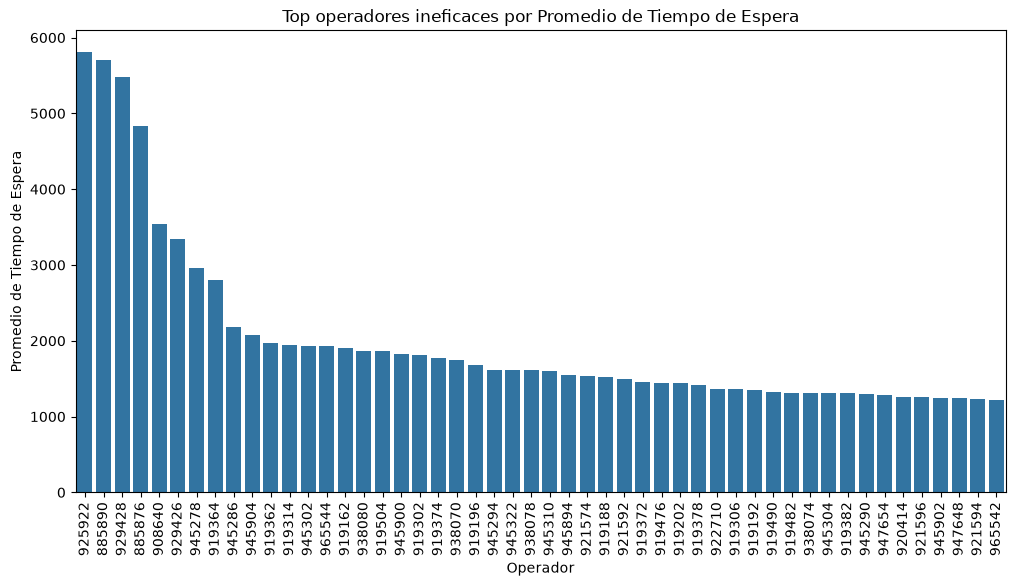

In [46]:
# Top Tiempo de Espera -> Gráfico
top_ineffective_avg_wait = (
    operator_stats[operator_stats['ineffective'] == True]
    .sort_values('avg_wait', ascending = False)
    .head(50)
    .reset_index()
)

plt.figure(figsize = (12,6)) 
sns.barplot(
    data = top_ineffective_avg_wait,
    x = 'operator_id',
    y = 'avg_wait'
)
plt.title('Top operadores ineficaces por Promedio de Tiempo de Espera')
plt.xlabel('Operador')
plt.ylabel('Promedio de Tiempo de Espera')
plt.xticks(rotation=90)
plt.show()

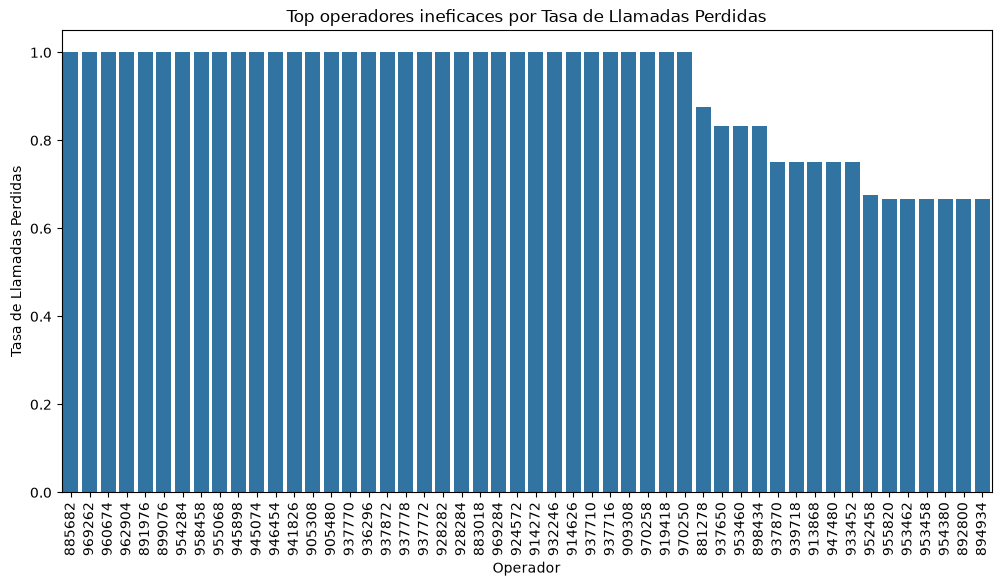

In [50]:
# Top Llamadas perdidas -> Gráfico
top_ineffective_missed_rate = (
    operator_stats[operator_stats['ineffective'] == True]
    .sort_values('miss_rate', ascending = False)
    .head(50)
    .reset_index()
)

plt.figure(figsize = (12,6)) 
sns.barplot(
    data = top_ineffective_missed_rate,
    x = 'operator_id',
    y = 'miss_rate'
)
plt.title('Top operadores ineficaces por Tasa de Llamadas Perdidas')
plt.xlabel('Operador')
plt.ylabel('Tasa de Llamadas Perdidas')
plt.xticks(rotation=90)
plt.show()

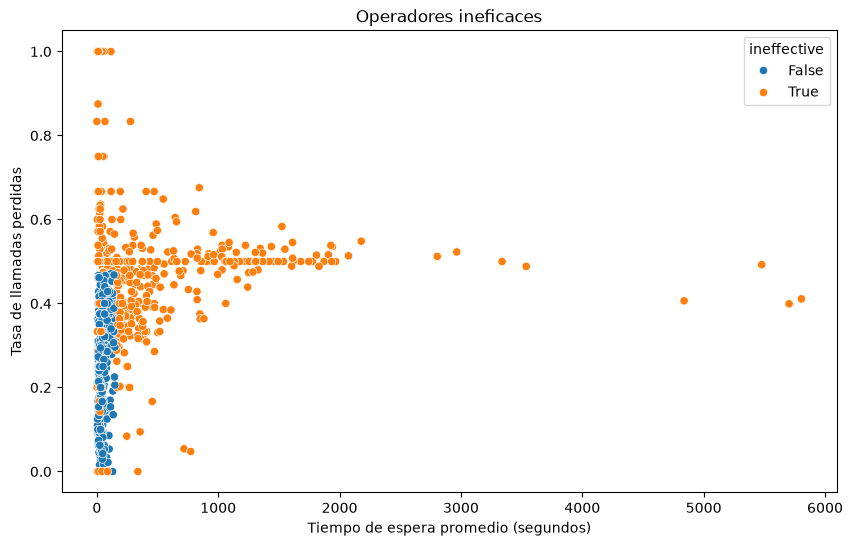

In [34]:
# Visualización de operadores Ineficaces
plt.figure(figsize=(10,6))
sns.scatterplot(
    data = operator_stats,
    x = 'avg_wait',
    y = 'miss_rate',
    hue = 'ineffective'
)
plt.title('Operadores ineficaces')
plt.xlabel('Tiempo de espera promedio (segundos)')
plt.ylabel('Tasa de llamadas perdidas')
plt.show()

#### Conclusiones
1. Se identificó una proporción importante de operadores con señales de ineficiencia.
Aplicando criterios basados en tasa de llamadas perdidas, tiempo promedio de espera y volumen de llamadas salientes, se detectaron 607 operadores clasificados como ineficaces, lo que indica que una parte considerable presenta comportamientos alejados del desempeño esperado.

2. Los operadores ineficaces presentan tasas elevadas de llamadas perdidas.
Se observan múltiples operadores con 100% de llamadas perdidas, aunque muchos poseen volúmenes extremadamente bajos (1–3 llamadas). Esto sugiere que algunos casos pueden estar influenciados por poca actividad y no necesariamente representar un desempeño operacional real.

3. Los tiempos de espera prolongados aparecen asociados a ineficiencia.
En el ranking de espera aparecen operadores con valores muy altos (superiores a 5000 segundos promedio), lo que puede indicar problemas de asignación, saturación o cuellos de botella operacionales.

4. Existe una relación visible entre mayor espera y peor desempeño.
El gráfico de dispersión muestra una concentración de operadores ineficaces en zonas de altos tiempos promedio de espera y mayores tasas de llamadas perdidas, indicando una posible asociación entre ambas variables.

5. El volumen de actividad afecta la interpretación.
Muchos operadores clasificados como ineficaces tienen solo 1 o 2 llamadas salientes, por lo que sus métricas son inestables. Un operador con una llamada perdida sobre una llamada total alcanza automáticamente 100% de pérdida.

### Pruebas de Hipótesis Estadísticas

Con el objetivo de validar si existen diferencias significativas entre operadores eficientes e ineficientes, se realizaron pruebas estadísticas sobre métricas clave de desempeño. Estas pruebas permiten determinar si los patrones observados durante el análisis exploratorio corresponden a diferencias reales en la operación o si podrían atribuirse al azar.

En particular, se evaluó si los operadores clasificados como ineficientes presentan tiempos de espera superiores a los operadores eficientes, ya que esta métrica impacta directamente la experiencia del cliente y la calidad del servicio prestado.

La pregunta de negocio que debemos formular es: _¿Los operadores ineficientes presentan tiempos de espera significativamente mayores que los operadores eficientes?_

Por lo tanto, se realizará las Pruebas de Hipótesis correspondiente por cada parámetro determinado para calificar a un operador ineficiente.

Comparación de Operadores Eficaces vs Ineficaces según tiempo promedio de espera:
* H0 -> El tiempo promedio de espera es igual entre operadores eficaces e ineficaces
* H1 -> El tiempo promedio de espera de los operadores ineficaces presentan tiempos de espera mayores

In [35]:
# Librería
from scipy import stats

In [36]:
# Segmentación de Grupos de Operadores
good_avg_wait = operator_stats[operator_stats['ineffective'] == False]['avg_wait']
bad_avg_wait = operator_stats[operator_stats['ineffective'] == True]['avg_wait']

In [37]:
# Prueba de Hipótesis
alpha = 0.05

results_p1 = stats.mannwhitneyu(
    good_avg_wait,
    bad_avg_wait
)

print(results_p1.pvalue)

4.7344665840115064e-08


In [38]:
# Conclusión Prueba de Hipótesis
if results_p1.pvalue < alpha:
    print('Rechazar H0: El tiempo promedio de espera de los operadores ineficaces presentan tiempos de espera mayores')
else:
    print('No rechazar H0: El tiempo promedio de espera es igual entre operadores eficaces e ineficaces')

Rechazar H0: El tiempo promedio de espera de los operadores ineficaces presentan tiempos de espera mayores


Comparación de Operadores Eficaces vs Ineficaces según la tasa de llamadas perdidas:
* H0 -> La tasa de llamadas perdidas es igual entre operadores eficaces e ineficaces
* H1 -> La tasa de llamadas perdidas de los operadores ineficaces presentan una tasa mayor

In [39]:
# Segmentación de Grupos de Operadores
good_miss_rate = operator_stats[operator_stats['ineffective'] == False]['miss_rate']
bad_miss_rate = operator_stats[operator_stats['ineffective'] == True]['miss_rate']

In [40]:
# Prueba de Hipótesis
alpha = 0.05

results_p2 = stats.mannwhitneyu(
    good_miss_rate,
    bad_miss_rate
)

print(results_p2.pvalue)

1.416415999114729e-27


In [41]:
# Conclusión Prueba de Hipótesis
if results_p2.pvalue < alpha:
    print('Rechazar H0: La tasa de llamadas perdidas de los operadores ineficaces presentan una tasa mayor')
else:
    print('No rechazar H0: La tasa de llamadas perdidas es igual entre operadores eficaces e ineficaces')

Rechazar H0: La tasa de llamadas perdidas de los operadores ineficaces presentan una tasa mayor


Comparación de Operadores Eficaces vs Ineficaces según cantidad de llamadas salientes:
* H0 -> La cantidad de llamadas salientes es igual entre operadores eficaces e ineficaces
* H1 -> La cantidad de llamadas salientes de los operadores ineficaces presentan una menor cantidad de llamadas salientes

In [42]:
#Segmentación de Grupos de Operarios
good_out_calls = operator_stats[operator_stats['ineffective'] == False]['out_calls']
bad_out_calls = operator_stats[operator_stats['ineffective'] == True]['out_calls']

In [43]:
# Prueba de Hipótesis
alpha = 0.05

results_p3 = stats.mannwhitneyu(
    good_out_calls,
    bad_out_calls
)

print(results_p3.pvalue)

0.0023667916520088055


In [44]:
# Conclusión Prueba de Hipótesis
if results_p3.pvalue < alpha:
    print('Rechazar H0: La cantidad de llamadas salientes de los operadores ineficaces presentan una menor cantidad de llamadas salientes')
else:
    print('No rechazar H0: La cantidad de llamadas salientes es igual entre operadores eficaces e ineficaces')

Rechazar H0: La cantidad de llamadas salientes de los operadores ineficaces presentan una menor cantidad de llamadas salientes


#### Conclusiones
Existe evidencia estadísticamente significativa para afirmar que los operadores clasificados como ineficaces presentan tiempos promedio de espera diferentes y mayores que los operadores eficaces. Esto respalda la utilización del tiempo de espera como criterio relevante para detectar ineficiencia operativa.

Se encontraron diferencias estadísticamente significativas entre ambos grupos. Los operadores ineficaces presentan mayores tasas de llamadas perdidas, lo que sugiere que este indicador es una señal importante para evaluar desempeño.

Existe evidencia suficiente para afirmar que los operadores eficaces e ineficaces difieren en su nivel de actividad saliente. Los operadores considerados ineficaces tienden a presentar un menor volumen de llamadas salientes, reforzando el criterio utilizado en la clasificación.

Por lo tanto, las pruebas estadísticas validaron los criterios utilizados para identificar operadores ineficaces. Se observó que el tiempo de espera, la tasa de llamadas perdidas y el volumen de llamadas salientes presentan diferencias significativas entre operadores eficaces e ineficaces. Esto indica que las métricas seleccionadas capturan comportamientos reales del desempeño operacional y pueden utilizarse para desarrollar sistemas de monitoreo orientados a supervisores.

## __Conclusión Proyecto__
El análisis permitió entender mejor cómo trabajan los operadores y qué características pueden indicar un desempeño poco eficiente. Durante el proceso se observó que variables como el tiempo de espera y las llamadas perdidas tienen un impacto importante en la calidad del servicio.

A medida que se avanzó en el análisis, aparecieron patrones claros: algunos operadores concentraban mayores tiempos de espera y tasas elevadas de llamadas perdidas. Las pruebas estadísticas confirmaron que estas diferencias no parecen ser aleatorias, sino que realmente existen diferencias entre operadores eficaces e ineficaces.

Finalmente, este proyecto demuestra que, utilizando datos y métricas adecuadas, es posible identificar oportunidades de mejora y generar herramientas que ayuden a optimizar la operación diaria.